# Uniform ORN / PN / LN Lateralization Across MCNS, FAFB and BANC

Three **contra / ipsi synapse-count ratios**, computed identically across the three public
*Drosophila* connectome datasets (Male-CNS via neuPrint, FAFB via FlyWire, BANC).

| Metric | Definition | ipsi / contra reference |
|---|---|---|
| **R_contra** | per ORN: output synapses in the **contralateral** AL / **ipsilateral** AL | AL the synapse sits in vs ORN soma side |
| **P_PN** | per ORN type: ORN→ALPN synapses from **contra** vs **ipsi** antenna | AL the synapse sits in vs ORN soma side |
| **P_LN** | per ORN type: ORN→ALLN synapses from **contra** vs **ipsi** antenna | AL the synapse sits in vs ORN soma side |

All three reference the **AL (neuropil) side of each synapse**, *not* the post-neuron's
soma side — so bilateral PNs whose soma sits across the midline from their dendrites
(e.g. `V_ilPN`, `VL1_ilPN`) are scored by where the synapse actually is.

Data sources: FAFB/BANC read the per-edge `neuropil` from their local connection files.
MCNS R_contra uses `roiInfo` AL(L)/AL(R); MCNS P_PN/P_LN use a **cached neuPrint fetch**
(`data/Male_CNS/orn_to_alpnln_AL_roi_adj.feather`) of every ORN→ALPN/ALLN connection
resolved by AL(L)/AL(R), since the MCNS edge feather lacks per-synapse ROI. The fetch runs
once (needs `NEUPRINT_TOKEN`) then reads from cache.

**Plotting** uses the **raw `contra/ipsi` ratio**: `0` = fully ipsilateral (the origin),
`1` = balanced, `>1` = contra-dominant. This keeps fully-ipsi glomeruli at 0 instead of a
count-dependent log extreme. A few genuine high-contra (or `ipsi=0` → ∞) values are clipped
to a per-plot `cap` and drawn with a distinct marker (open diamond / red ring / red ✕).
The CSV also keeps `ratio` and `log2_ratio`.

In [1]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns

sns.set_context('notebook')
sns.set_style('whitegrid')
# setup dark background for all subsequent plots (overridden by plt.style.use('default') if needed):
plt.style.use('dark_background')
DATA = '../data'
EPS = 1e-9

# --- uniform helpers -------------------------------------------------------
_SIDE = {'L': 'left', 'R': 'right', 'left': 'left', 'right': 'right'}
def norm_side(s):
    '''Map L/R/left/right -> left/right; everything else (M/midline/unknown/nan) -> None.'''
    return _SIDE.get(str(s).strip(), None)

def glom(t):
    '''ORN type name -> glomerulus label, e.g. "ORN_DA1" -> "DA1". Non-ORN -> None.'''
    t = str(t)
    return t[4:] if t.startswith('ORN_') else None

def is_orn(t):
    return str(t).startswith('ORN_')

def log2r(contra, ipsi, pc=1.0):
    '''Symmetric log2 contra/ipsi ratio with a pseudocount (robust to zeros).'''
    return np.log2((np.asarray(contra, float) + pc) / (np.asarray(ipsi, float) + pc))

def cratio(contra, ipsi):
    '''Raw contra/ipsi ratio: 0 = fully ipsilateral, 1 = balanced, >1 = contra-dominant.
    ipsi==0 with contra>0 -> +inf (a "fully contra" extremum); 0/0 -> NaN.'''
    contra = np.asarray(contra, float); ipsi = np.asarray(ipsi, float)
    with np.errstate(divide='ignore', invalid='ignore'):
        r = contra / ipsi
    r[(ipsi == 0) & (contra == 0)] = np.nan
    return r

def cap_extreme(vals, cap):
    '''For plotting on a raw-ratio axis: clip values to `cap` and flag which were
    extreme (non-finite or > cap) so they can be drawn/marked separately.'''
    v = np.asarray(vals, float)
    extreme = ~np.isfinite(v) | (v > cap)
    return np.where(extreme, cap, v), extreme

## 1. Per-dataset loaders
Each returns `(metric1_df, edges23_df)` with identical schemas.

In [2]:
def load_mcns():
    '''Male-CNS (neuPrint). neurons.pkl is the user's own locally-cached fetch_neurons()
    output (trusted). R_contra comes from roiInfo AL(L)/AL(R) 'downstream'. For P_PN/P_LN
    the MCNS edge feather has no per-edge ROI, so we use a cached neuPrint adjacency fetch
    that resolves every ORN->ALPN/ALLN connection by AL(L)/AL(R) -- giving the same
    per-synapse AL reference as FAFB/BANC (so bilateral ilPNs are scored correctly).'''
    with open(f'{DATA}/Male_CNS/neurons.pkl', 'rb') as f:
        meta = pickle.load(f)[0].copy()

    side = meta['rootSide'].map(norm_side)
    side = side.fillna(meta['somaSide'].map(norm_side))
    meta['side'] = side
    cls = meta['class'].astype(str)
    typ = meta['flywireType'].astype(str)
    meta['role'] = np.select(
        [typ.map(is_orn), cls.eq('ALPN'), cls.eq('ALLN')],
        ['ORN', 'ALPN', 'ALLN'], default=None)
    meta['glomerulus'] = np.where(meta['role'] == 'ORN', typ.map(glom), None)

    def alfield(roi, key, field):
        d = roi.get(key, {}) if isinstance(roi, dict) else {}
        return d.get(field, 0) or 0

    # ---- metric 1: ORN output synapses per AL from roiInfo ('downstream') ----
    orns = meta[(meta['role'] == 'ORN') & meta['side'].notna() & meta['glomerulus'].notna()].copy()
    al_L = orns['roiInfo'].apply(lambda r: alfield(r, 'AL(L)', 'downstream'))
    al_R = orns['roiInfo'].apply(lambda r: alfield(r, 'AL(R)', 'downstream'))
    m1 = pd.DataFrame({
        'dataset': 'MCNS', 'neuron_id': orns['bodyId'].values,
        'glomerulus': orns['glomerulus'].values, 'side': orns['side'].values,
        'ipsi_syn':   np.where(orns['side'].eq('left'), al_L, al_R),
        'contra_syn': np.where(orns['side'].eq('left'), al_R, al_L),
    })

    # ---- metrics 2 & 3: ORN -> ALPN/ALLN, resolved by AL(L)/AL(R) (cached neuPrint fetch) ----
    postn = meta[meta['role'].isin(['ALPN', 'ALLN']) & meta['side'].notna()]
    cache = f'{DATA}/Male_CNS/orn_to_alpnln_AL_roi_adj.feather'
    if os.path.exists(cache):
        roi = pd.read_feather(cache)
    else:
        from dotenv import load_dotenv
        from neuprint import Client, fetch_adjacencies, set_default_client
        load_dotenv()
        cl = Client('https://neuprint.janelia.org', dataset='male-cns:v0.9',
                    token=os.getenv('NEUPRINT_TOKEN'))
        set_default_client(cl)
        _, roi = fetch_adjacencies(sources=orns['bodyId'].astype(int).tolist(),
                                   targets=postn['bodyId'].astype(int).tolist(),
                                   rois=['AL(L)', 'AL(R)'], client=cl)
        roi.to_feather(cache)

    id2side = meta.set_index('bodyId')['side']
    id2role = meta.set_index('bodyId')['role']
    id2glom = orns.set_index('bodyId')['glomerulus']
    roi_side = roi['roi'].map({'AL(L)': 'left', 'AL(R)': 'right'})
    e23 = pd.DataFrame({
        'dataset': 'MCNS',
        'glomerulus': roi['bodyId_pre'].map(id2glom).values,
        'post_role': roi['bodyId_post'].map(id2role).values,
        'weight': roi['weight'].values,
        # ipsi = ORN soma side matches the AL the synapse sits in
        'ipsi': (roi['bodyId_pre'].map(id2side).values == roi_side.values),
    })
    return m1, e23

In [3]:
_NP_SIDE = {'AL_L': 'left', 'AL_R': 'right'}

def _process_cave(dataset, conn_csv, nb, chunksize=None):
    '''Compute (metric1_df, edges23_df) from a CAVE-style connections file given
    standardized neuron metadata `nb` (columns: id, side, role, glomerulus).
    All ipsi/contra calls use the AL NEUROPIL side of each synapse vs the ORN soma
    side -- so bilateral PNs (soma contralateral to dendrite, e.g. ilPNs) are scored
    by where the synapse actually sits, consistent with the ORN-axon metric.'''
    nb = nb.copy()
    nb['id'] = nb['id'].astype('int64')
    orns = nb[(nb['role'] == 'ORN') & nb['side'].notna() & nb['glomerulus'].notna()]
    orn_ids = set(orns['id'])
    post = nb[nb['role'].isin(['ALPN', 'ALLN']) & nb['side'].notna()]
    post_ids = set(post['id'])
    id2side = nb.set_index('id')['side']
    id2role = nb.set_index('id')['role']
    id2glom = orns.set_index('id')['glomerulus']

    usecols = ['pre_root_id', 'post_root_id', 'neuropil', 'syn_count']
    m1_parts, e23_parts = [], []
    reader = pd.read_csv(conn_csv, usecols=usecols, chunksize=chunksize)
    for ch in (reader if chunksize else [reader]):
        c = ch[ch['pre_root_id'].isin(orn_ids) & ch['neuropil'].isin(['AL_L', 'AL_R'])]
        if len(c) == 0:
            continue
        m1_parts.append(c[['pre_root_id', 'neuropil', 'syn_count']])
        e23_parts.append(c[c['post_root_id'].isin(post_ids)][['pre_root_id', 'post_root_id', 'neuropil', 'syn_count']])

    a = pd.concat(m1_parts, ignore_index=True) if m1_parts else pd.DataFrame(columns=['pre_root_id', 'neuropil', 'syn_count'])
    piv = a.groupby(['pre_root_id', 'neuropil'])['syn_count'].sum().unstack(fill_value=0)
    for col in ['AL_L', 'AL_R']:
        if col not in piv: piv[col] = 0
    piv = piv.reindex(orns['id'].values).fillna(0)
    oside = orns.set_index('id')['side'].reindex(piv.index)
    m1 = pd.DataFrame({
        'dataset': dataset, 'neuron_id': piv.index.values,
        'glomerulus': orns.set_index('id')['glomerulus'].reindex(piv.index).values,
        'side': oside.values,
        'ipsi_syn':   np.where(oside.eq('left').values, piv['AL_L'].values, piv['AL_R'].values),
        'contra_syn': np.where(oside.eq('left').values, piv['AL_R'].values, piv['AL_L'].values),
    })

    b = pd.concat(e23_parts, ignore_index=True) if e23_parts else pd.DataFrame(columns=['pre_root_id', 'post_root_id', 'neuropil', 'syn_count'])
    e23 = pd.DataFrame({
        'dataset': dataset,
        'glomerulus': b['pre_root_id'].map(id2glom).values,
        'post_role': b['post_root_id'].map(id2role).values,
        'weight': b['syn_count'].values,
        # ipsi = ORN soma side matches the AL the synapse sits in (PN dendrite side)
        'ipsi': (b['pre_root_id'].map(id2side).values == b['neuropil'].map(_NP_SIDE).values),
    })
    return m1, e23


def load_fafb():
    '''FAFB (FlyWire): ORN = hemibrain_type ORN_*, ALPN/ALLN = class.'''
    nb = pd.read_csv(f'{DATA}/FlyWire/classification.csv.gz')
    nb = nb.rename(columns={'root_id': 'id', 'hemibrain_type': 'type'})
    nb['side'] = nb['side'].map(norm_side)
    typ = nb['type'].astype(str)
    nb['role'] = np.select(
        [typ.map(is_orn), nb['class'].eq('ALPN'), nb['class'].eq('ALLN')],
        ['ORN', 'ALPN', 'ALLN'], default=None)
    nb['glomerulus'] = np.where(nb['role'] == 'ORN', typ.map(glom), None)
    return _process_cave('FAFB', f'{DATA}/FlyWire/connections_princeton_no_threshold.csv.gz',
                         nb, chunksize=3_000_000)


def load_banc():
    '''BANC: newer annotation `neurons.pickle.gz` — a dict keyed by root_id -> attribute
    dict (the user's own local CAVE export, trusted). ORN = class olfactory_receptor_neuron
    with an ORN_* resolved_type; ALPN/ALLN = antennal_lobe_(projection|local)_neuron.'''
    raw = pd.read_pickle(f'{DATA}/BANC/neurons.pickle.gz')
    nb = pd.DataFrame.from_dict(raw, orient='index').reset_index(drop=True)
    nb = nb.rename(columns={'root_id': 'id', 'resolved_type': 'type'})
    nb['side'] = nb['side'].map(norm_side)
    cls = nb['class'].astype(str)
    nb['role'] = np.select(
        [cls.eq('olfactory_receptor_neuron'),
         cls.eq('antennal_lobe_projection_neuron'),
         cls.eq('antennal_lobe_local_neuron')],
        ['ORN', 'ALPN', 'ALLN'], default=None)
    # glomerulus only for true ORN_* labels (drops bare 'ORN' / 'D_ORN' fragments)
    nb['glomerulus'] = np.where(nb['role'] == 'ORN', nb['type'].astype(str).map(glom), None)
    return _process_cave('BANC', f'{DATA}/BANC/connections_princeton.csv.gz', nb)

## 2. Load all three datasets
(The MCNS pickle and feather are large; this cell takes ~1 min.)

In [4]:
loaders = {'MCNS': load_mcns, 'FAFB': load_fafb, 'BANC': load_banc}
m1_all, e23_all = [], []
for name, fn in loaders.items():
    m1, e23 = fn()
    m1_all.append(m1); e23_all.append(e23)
    print(f'{name}: {len(m1):>5d} ORNs | {len(e23):>8d} ORN->PN/LN edges')

metric1_df = pd.concat(m1_all, ignore_index=True)
edges23_df = pd.concat(e23_all, ignore_index=True).dropna(subset=['glomerulus', 'post_role'])

MCNS:  2226 ORNs |   155472 ORN->PN/LN edges
FAFB:  2247 ORNs |   117765 ORN->PN/LN edges
BANC:  2970 ORNs |    33793 ORN->PN/LN edges


## 3. Uniform tidy summary table
Pooled per (dataset, glomerulus, metric): ipsi / contra synapse totals and the contra/ipsi ratio.

In [5]:
g1 = metric1_df.groupby(['dataset', 'glomerulus']).agg(
        ipsi_syn=('ipsi_syn', 'sum'), contra_syn=('contra_syn', 'sum'),
        n=('neuron_id', 'nunique')).reset_index()
g1['metric'] = 'R_contra'

def summarise_edges(role, label):
    sub = edges23_df[edges23_df['post_role'] == role]
    g = sub.groupby(['dataset', 'glomerulus', 'ipsi'])['weight'].sum().unstack(fill_value=0)
    for col in [True, False]:
        if col not in g: g[col] = 0
    g = g.rename(columns={True: 'ipsi_syn', False: 'contra_syn'}).reset_index()
    cnt = sub.groupby(['dataset', 'glomerulus']).size().rename('n').reset_index()
    g = g.merge(cnt, on=['dataset', 'glomerulus'], how='left')
    g['metric'] = label
    return g[['dataset', 'glomerulus', 'ipsi_syn', 'contra_syn', 'n', 'metric']]

summary = pd.concat([g1, summarise_edges('ALPN', 'P_PN'),
                     summarise_edges('ALLN', 'P_LN')], ignore_index=True)
summary['ratio'] = summary['contra_syn'] / (summary['ipsi_syn'] + EPS)
summary['log2_ratio'] = log2r(summary['contra_syn'], summary['ipsi_syn'])
summary = summary[['dataset', 'glomerulus', 'metric', 'ipsi_syn', 'contra_syn', 'n', 'ratio', 'log2_ratio']]
summary.to_csv('ORN-lateralization-multi.csv', index=False)
print('saved ORN-lateralization-multi.csv  ', summary.shape)
summary.head()

saved ORN-lateralization-multi.csv   (474, 8)


,dataset,glomerulus,metric,ipsi_syn,contra_syn,n,ratio,log2_ratio
0,BANC,D,R_contra,2166.0,672.0,29,0.310249,-1.687021
1,BANC,DA1,R_contra,14314.0,1602.0,224,0.111918,-3.158681
2,BANC,DA2,R_contra,1505.0,390.0,37,0.259136,-1.945481
3,BANC,DA3,R_contra,403.0,62.0,22,0.153846,-2.680932
4,BANC,DA4l,R_contra,533.0,75.0,28,0.140713,-2.812768


## 4. Common glomeruli (present in all three datasets)

In [6]:
common = sorted(set.intersection(*metric1_df.groupby('dataset')['glomerulus'].agg(set).tolist()))
print(f'{len(common)} glomeruli common to all three datasets:')
print(', '.join(common))

DS_ORDER = ['MCNS', 'FAFB', 'BANC']
METRICS = [('R_contra', r'$R_{contra}$'),
           ('P_PN', r'$P_{PN}$'),
           ('P_LN', r'$P_{LN}$')]

49 glomeruli common to all three datasets:
D, DA1, DA2, DA3, DA4l, DA4m, DC1, DC2, DC3, DC4, DL1, DL2d, DL2v, DL3, DL4, DL5, DM1, DM2, DM3, DM4, DM5, DM6, DP1l, DP1m, V, VA1d, VA1v, VA2, VA3, VA4, VA5, VA6, VA7l, VA7m, VC1, VC2, VC4, VC5, VL1, VL2a, VL2p, VM1, VM2, VM3, VM4, VM5d, VM5v, VM7d, VM7v


## 5. Cross-dataset comparison — heatmaps

One panel per metric, glomeruli (rows) shared across panels, datasets as columns.
Colour = **raw `contra/ipsi` ratio**: **blue ≈ 0 = ipsi-dominant, white = 1 = balanced,
red > 1 = contra-dominant**. Rows ordered by mean R_contra ratio.

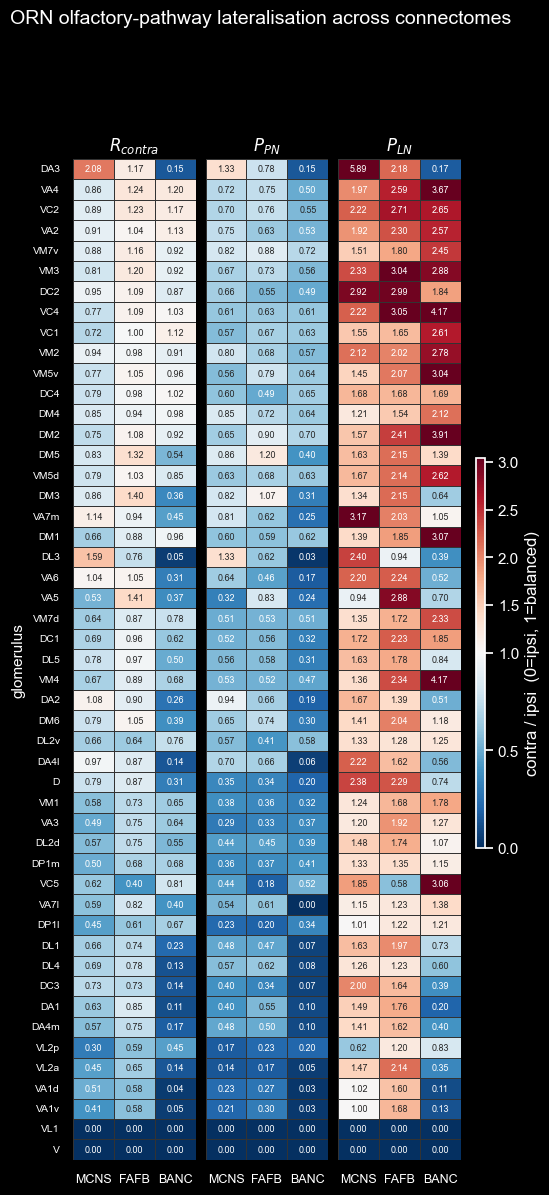

In [7]:
plot = summary[summary['glomerulus'].isin(common)].copy()
plot['r'] = cratio(plot['contra_syn'], plot['ipsi_syn'])   # 0 = ipsi, 1 = balanced, >1 = contra

# diverging colour centred on 1 (balanced); 0 = fully ipsi (blue), >1 = contra (red)
vmax = float(np.nanquantile(plot['r'], 0.98))
norm = TwoSlopeNorm(vcenter=1.0, vmin=0.0, vmax=max(vmax, 1.5))

# row order by mean R_contra ratio (most contralateral at top, most ipsi at bottom)
ax_order = (plot[plot['metric'] == 'R_contra']
            .groupby('glomerulus')['r'].mean().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 3, figsize=(5, 13), sharey=True)
for ax, (metric, title) in zip(axes, METRICS):
    mat = (plot[plot['metric'] == metric]
           .pivot(index='glomerulus', columns='dataset', values='r')
           .reindex(index=ax_order, columns=DS_ORDER))
    sns.heatmap(mat, ax=ax, cmap='RdBu_r', norm=norm, cbar=False,
                annot=True, fmt='.2f', annot_kws={'size': 6.5},
                linewidths=0.4, linecolor='0.2', square=False)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=9, rotation=0)
    ax.tick_params(axis='y', labelsize=7.5)
axes[0].set_ylabel('glomerulus', fontsize=11)

fig.subplots_adjust(right=0.9, wspace=0.08)
cax = fig.add_axes([0.93, 0.35, 0.018, 0.3])
fig.colorbar(ScalarMappable(norm=norm, cmap='RdBu_r'), cax=cax,
             label='contra / ipsi  (0=ipsi, 1=balanced)')
fig.suptitle('ORN olfactory-pathway lateralisation across connectomes', y=0.995, fontsize=14)
plt.show()

## 6. Cross-dataset concordance — pooled ratio per glomerulus

Dot / lollipop view: marker per dataset, glomeruli sorted, dashed line at **1 = balanced**
(0 = fully ipsi). Open diamonds mark values clipped at the cap.

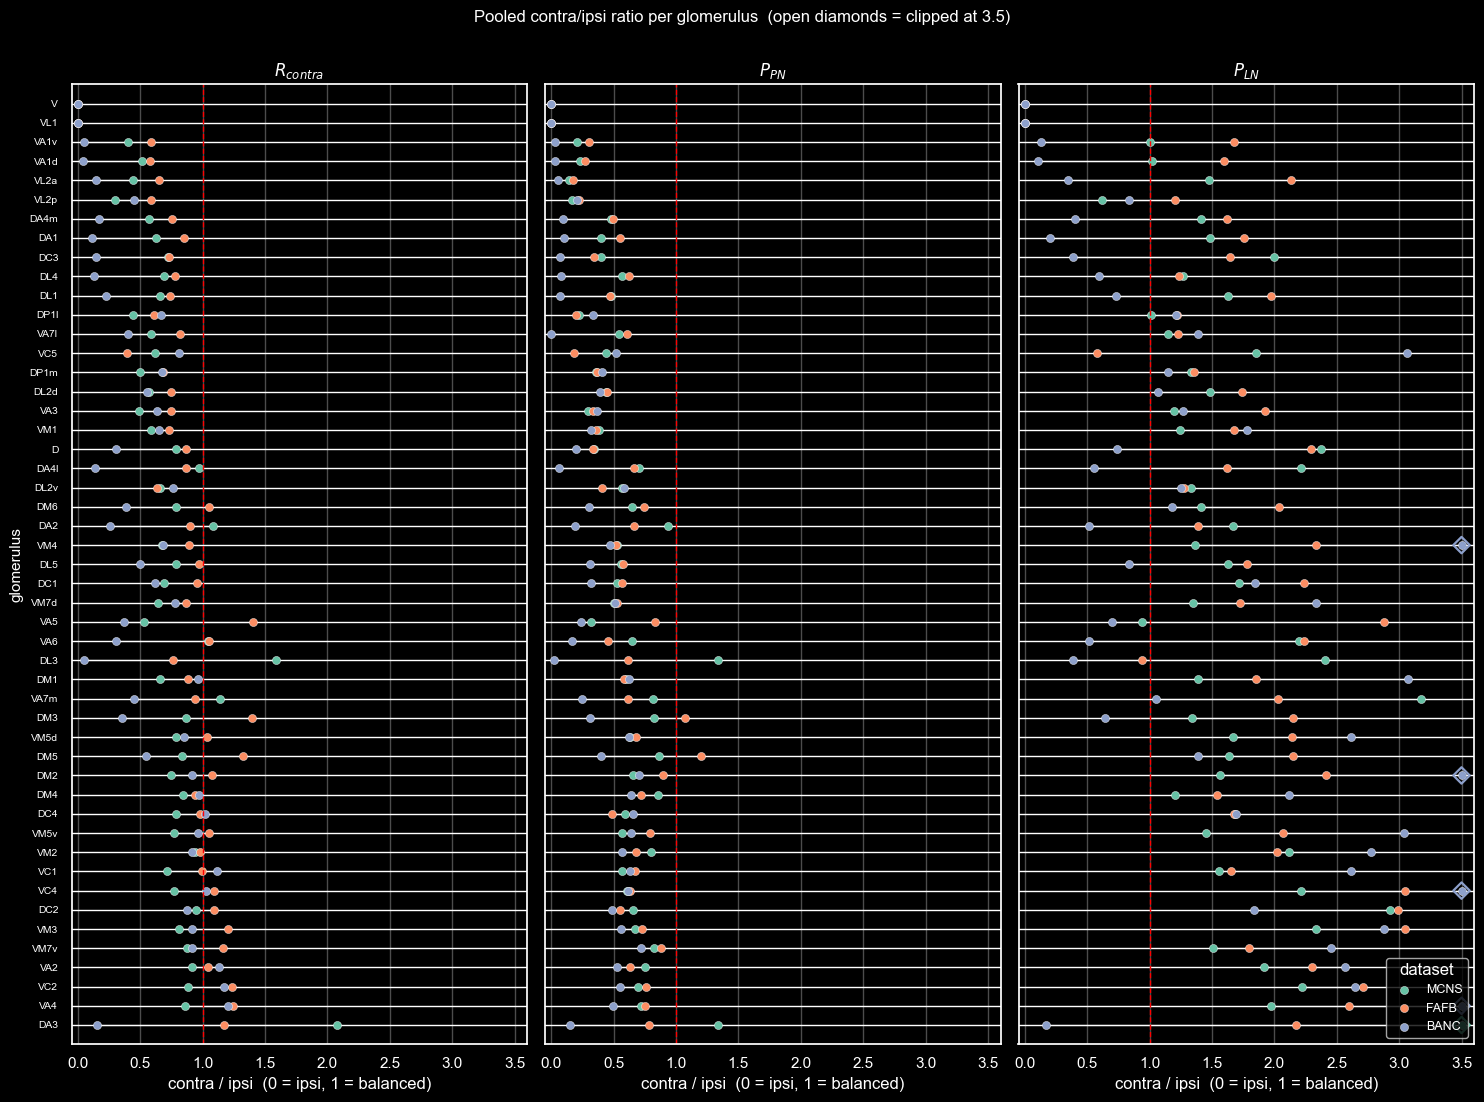

In [8]:
# raw contra/ipsi ratio per dataset; 0 = ipsi, dashed line at 1 = balanced.
# genuine high-contra extrema (or ipsi==0 -> inf) are clipped to `cap` and drawn as
# open diamonds so the bulk stays readable.
finite = plot['r'][np.isfinite(plot['r'])]
cap = float(np.ceil(np.nanquantile(finite, 0.98) * 2) / 2)  # round up to .5
fig, axes = plt.subplots(1, 3, figsize=(15, 11), sharey=True)
palette = dict(zip(DS_ORDER, sns.color_palette('Set2', 3)))
for ax, (metric, title) in zip(axes, METRICS):
    d = plot[plot['metric'] == metric].copy()
    d['x'], d['extreme'] = cap_extreme(d['r'], cap)
    order = d.groupby('glomerulus')['r'].mean().reindex(ax_order).index
    ypos = {g: i for i, g in enumerate(order)}
    for g in order:
        vals = d[d['glomerulus'] == g]['x']
        ax.plot([vals.min(), vals.max()], [ypos[g], ypos[g]], color='0.4', lw=1, zorder=0)
    for ds in DS_ORDER:
        dd = d[d['dataset'] == ds]
        ax.scatter(dd['x'], [ypos[g] for g in dd['glomerulus']],
                   s=34, c=[palette[ds]], label=ds, zorder=2,
                   marker='o', edgecolor='w', linewidth=0.3)
        ex = dd[dd['extreme']]
        ax.scatter(ex['x'], [ypos[g] for g in ex['glomerulus']],
                   s=70, facecolors='none', edgecolors=palette[ds], linewidth=1.6,
                   marker='D', zorder=3)
    ax.axvline(1.0, color='r', ls='--', lw=1)          # balanced
    ax.set_xlim(-0.05, cap + 0.1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('contra / ipsi  (0 = ipsi, 1 = balanced)')
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7.5)
    ax.set_ylim(-1, len(order))
    ax.grid(axis='x', alpha=0.3)
axes[0].set_ylabel('glomerulus', fontsize=11)
axes[2].legend(title='dataset', loc='lower right', fontsize=9)
fig.suptitle(f'Pooled contra/ipsi ratio per glomerulus  '
             f'(open diamonds = clipped at {cap:g})', y=1.0, fontsize=12)
plt.tight_layout()
plt.show()

## 7. Per-ORN spread of axon laterality

Distribution over individual ORNs (each contributes one raw `contra/ipsi` ratio), by
glomerulus, faceted by dataset. 0 = fully ipsi, dashed line at 1 = balanced. Individual
ORNs with `ipsi = 0` give ∞ and are clipped to the cap, marked with a red ✕.

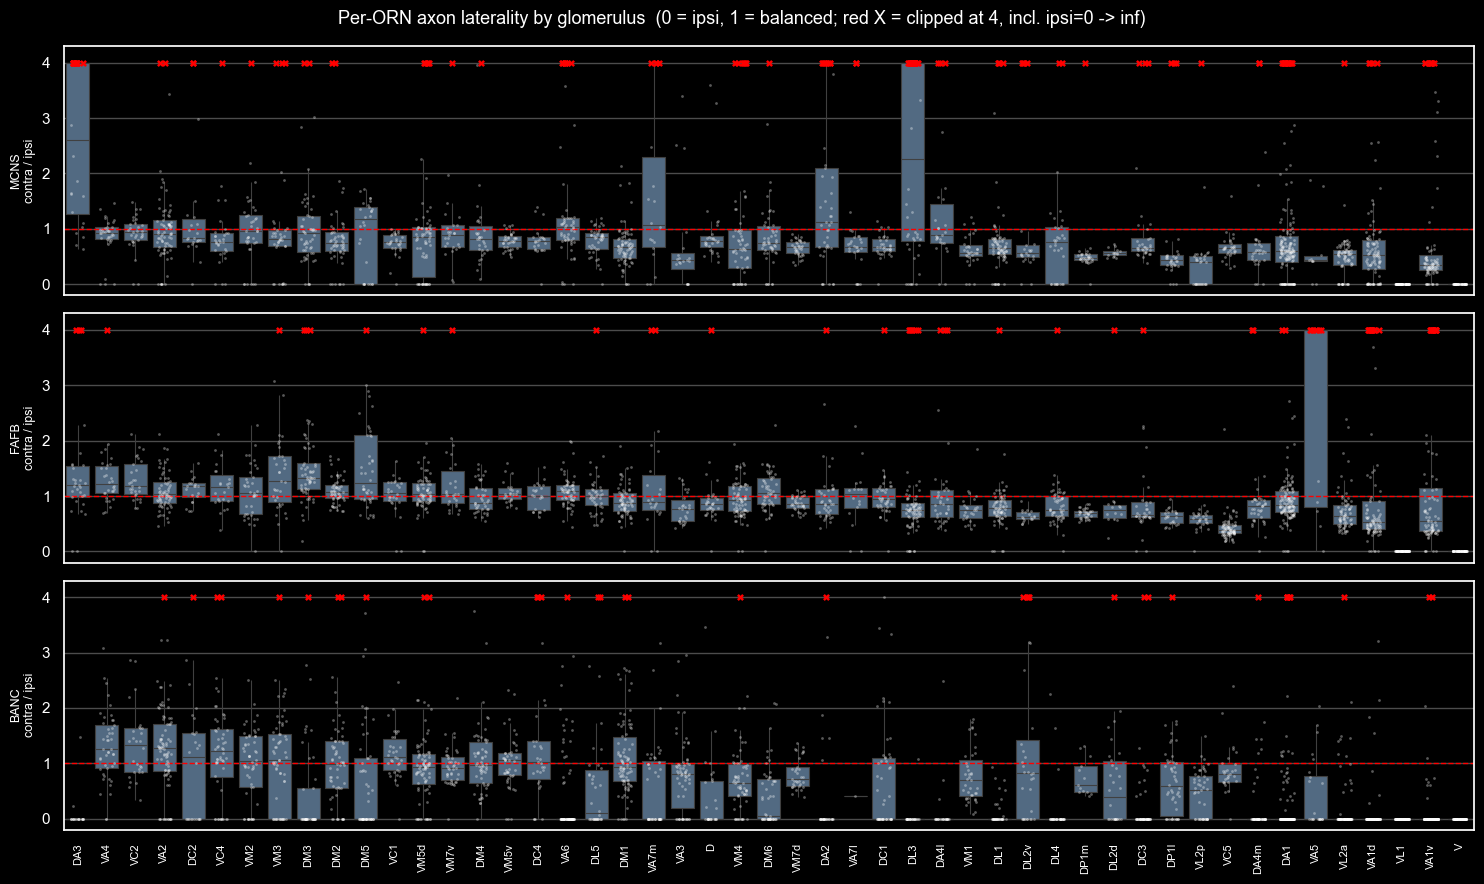

In [9]:
# per-ORN raw contra/ipsi ratio (0 = ipsi). Individual ORNs with ipsi==0 give +inf,
# so we clip to `cap` and mark those as red x's at the top; dashed line at 1 = balanced.
d = metric1_df[metric1_df['glomerulus'].isin(common)].copy()
d['r'] = cratio(d['contra_syn'], d['ipsi_syn'])
d = d.dropna(subset=['r'])
cap = float(np.ceil(np.nanquantile(d['r'][np.isfinite(d['r'])], 0.98)))
d['x'], d['extreme'] = cap_extreme(d['r'], cap)
order = d.groupby('glomerulus')['r'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(len(DS_ORDER), 1, figsize=(15, 9), sharex=True, sharey=True)
for ax, ds in zip(axes, DS_ORDER):
    dd = d[d['dataset'] == ds]
    sns.boxplot(data=dd, x='glomerulus', y='x', order=order, ax=ax,
                fliersize=0, color='#4a6a8a', showcaps=False, linewidth=0.8)
    sns.stripplot(data=dd[~dd['extreme']], x='glomerulus', y='x', order=order, ax=ax,
                  color='w', size=2, alpha=0.35, jitter=0.25)
    ex = dd[dd['extreme']]
    if len(ex):
        sns.stripplot(data=ex, x='glomerulus', y='x', order=order, ax=ax,
                      color='red', marker='X', size=5, jitter=0.2)
    ax.axhline(1.0, color='r', lw=1, ls='--')          # balanced
    ax.set_ylim(-0.2, cap + 0.3)
    ax.set_ylabel(f'{ds}\ncontra / ipsi', fontsize=9)
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)
axes[-1].tick_params(axis='x', rotation=90, labelsize=8)
fig.suptitle(f'Per-ORN axon laterality by glomerulus  '
             f'(0 = ipsi, 1 = balanced; red X = clipped at {cap:g}, incl. ipsi=0 -> inf)',
             fontsize=13)
plt.tight_layout()
plt.show()

## 8. Glomeruli in 3-D lateralisation space

One point per glomerulus = the **median across datasets** of each raw `contra/ipsi` ratio:
**R_contra**, **P_LN**, **P_PN**. The **origin (0,0,0) = fully ipsilateral** on all three
axes; dashed guides mark ratio = 1 (balanced). Colour encodes R_contra; clipped extrema
are ringed red.

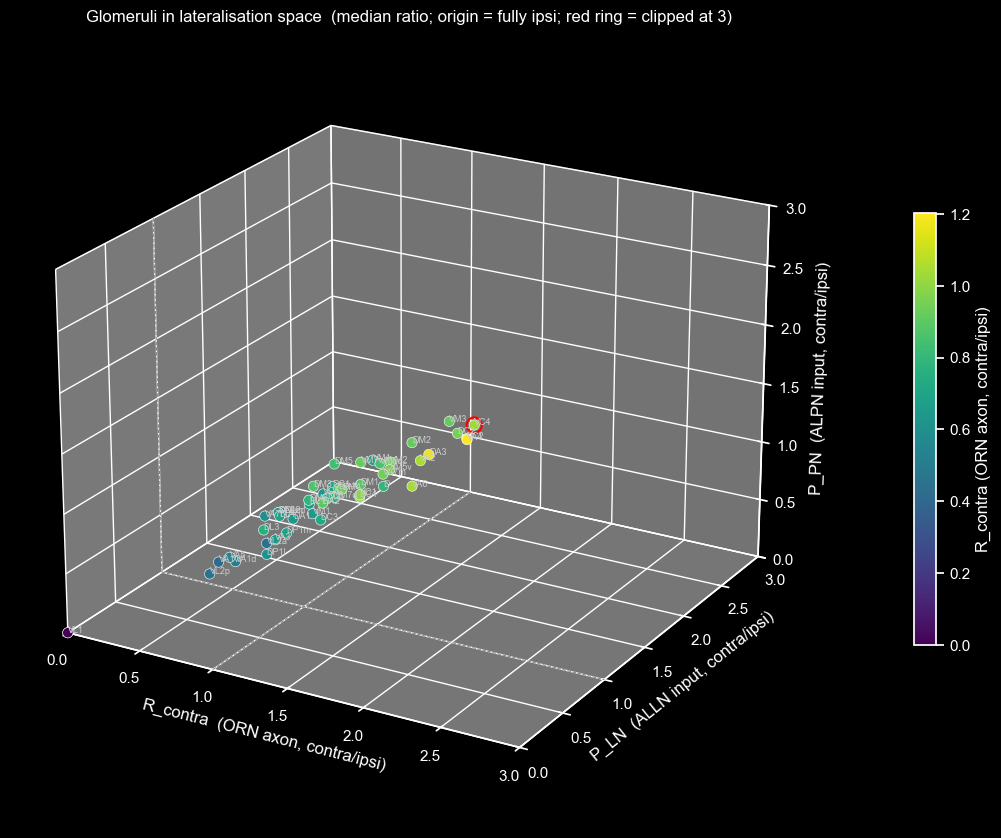

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

# axes = raw contra/ipsi ratio (0 = fully ipsi -> origin; 1 = balanced; >1 = contra)
AXES = [('R_contra', 'R_contra  (ORN axon, contra/ipsi)'),
        ('P_LN', 'P_LN  (ALLN input, contra/ipsi)'),
        ('P_PN', 'P_PN  (ALPN input, contra/ipsi)')]
xm, ym, zm = [m for m, _ in AXES]

# one point per glomerulus: median raw ratio across the three datasets
sp = summary[summary['glomerulus'].isin(common)].copy()
sp['r'] = cratio(sp['contra_syn'], sp['ipsi_syn'])
space = sp.groupby(['glomerulus', 'metric'])['r'].median().unstack('metric').reset_index()

cap = float(np.ceil(np.nanquantile(space[[xm, ym, zm]].values[np.isfinite(space[[xm, ym, zm]].values)], 0.98)))
extreme = np.zeros(len(space), bool)
for m in (xm, ym, zm):
    space[m], ex = cap_extreme(space[m], cap)
    extreme |= ex

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(space[xm], space[ym], space[zm], c=space[xm], cmap='viridis',
                s=55, edgecolor='w', linewidth=0.4, depthshade=False)
# clipped/extreme glomeruli ringed in red
if extreme.any():
    e = space[extreme]
    ax.scatter(e[xm], e[ym], e[zm], s=120, facecolors='none', edgecolors='red', linewidth=1.5)
for _, r in space.iterrows():
    ax.text(r[xm], r[ym], r[zm], r['glomerulus'], size=6.5, color='0.8')

# faint reference lines at ratio = 1 (balanced) on each axis
ax.plot([1, 1], [0, cap], [0, 0], color='0.5', lw=0.7, ls='--')
ax.plot([0, cap], [1, 1], [0, 0], color='0.5', lw=0.7, ls='--')
ax.plot([0, 0], [1, 1], [0, cap], color='0.5', lw=0.7, ls='--')

ax.set_xlabel(AXES[0][1]); ax.set_ylabel(AXES[1][1]); ax.set_zlabel(AXES[2][1])
ax.set_xlim(0, cap); ax.set_ylim(0, cap); ax.set_zlim(0, cap)
ax.view_init(elev=22, azim=-60)
ax.set_title(f'Glomeruli in lateralisation space  (median ratio; origin = fully ipsi; '
             f'red ring = clipped at {cap:g})')
fig.colorbar(sc, ax=ax, shrink=0.5, pad=0.1, label='R_contra (ORN axon, contra/ipsi)')
plt.tight_layout()
plt.show()

# Tip: run `%matplotlib widget` (needs ipympl) in a cell above for interactive rotation.

## 9. 2-D view: PN vs LN input laterality

The same space projected to 2-D — **P_PN** (x) vs **P_LN** (y) as raw `contra/ipsi` ratio,
one point per glomerulus (median across datasets). **Origin = fully ipsi**, dashed lines at
1 = balanced. Marker **colour = R_contra**, **size = median #ORNs**; clipped extrema ringed red.

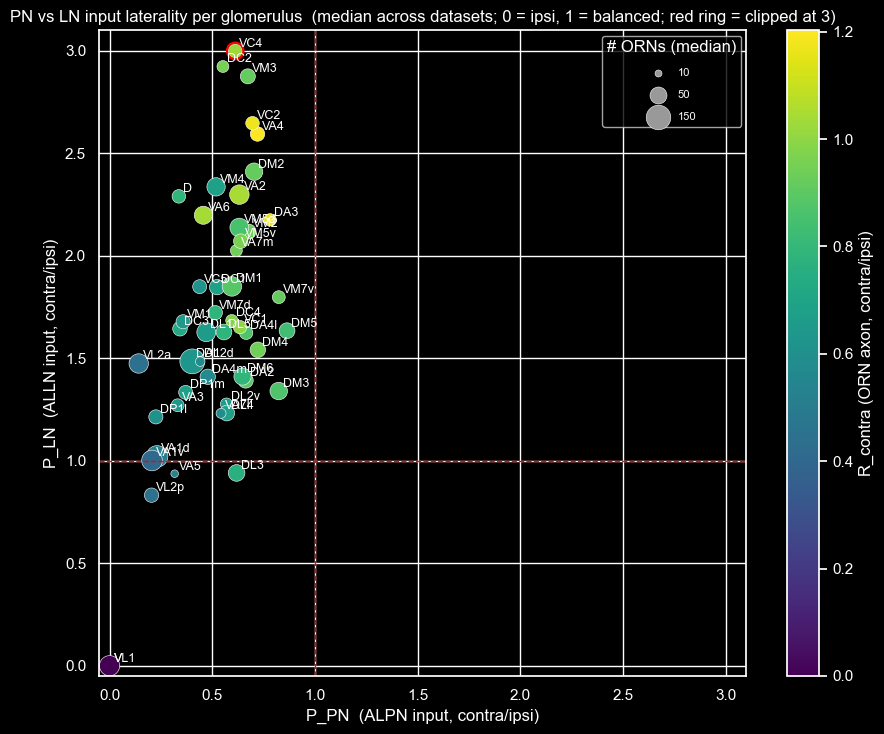

In [11]:
plt.style.use('dark_background')
# 2-D view: P_PN (x) vs P_LN (y) as raw contra/ipsi ratio, one point per glomerulus
# (median across datasets). 0 = fully ipsi (origin), 1 = balanced (dashed lines), >1 = contra.
# colour = R_contra ratio, size = median #ORNs. High-contra extrema clipped + ringed red.
sp = summary[summary['glomerulus'].isin(common)].copy()
sp['r'] = cratio(sp['contra_syn'], sp['ipsi_syn'])
piv = sp.groupby(['glomerulus', 'metric'])['r'].median().unstack('metric')
piv['n'] = sp[sp['metric'] == 'R_contra'].groupby('glomerulus')['n'].median()
piv = piv.reset_index()

cap = float(np.ceil(np.nanquantile(piv[['R_contra', 'P_PN', 'P_LN']].values[
    np.isfinite(piv[['R_contra', 'P_PN', 'P_LN']].values)], 0.98)))
extreme = np.zeros(len(piv), bool)
for c in ['R_contra', 'P_PN', 'P_LN']:
    piv[c], ex = cap_extreme(piv[c], cap)
    extreme |= ex

smin, smax = 30, 320
nn = piv['n'].fillna(0)
sizes = smin + (smax - smin) * (np.sqrt(nn) - np.sqrt(nn).min()) / (np.sqrt(nn).max() - np.sqrt(nn).min())

fig, ax = plt.subplots(figsize=(9, 7.5))
sc = ax.scatter(piv['P_PN'], piv['P_LN'], c=piv['R_contra'], cmap='viridis',
                s=sizes, edgecolor='w', linewidth=0.4, zorder=2)
ax.scatter(piv.loc[extreme, 'P_PN'], piv.loc[extreme, 'P_LN'],
           s=sizes[extreme] + 40, facecolors='none', edgecolors='red', linewidth=1.6, zorder=3)
for _, r in piv.iterrows():
    ax.annotate(r['glomerulus'], (r['P_PN'], r['P_LN']), fontsize=9,
                xytext=(3, 3), textcoords='offset points', color='white', zorder=4)
ax.axhline(1, color='r', lw=1, ls='--'); ax.axvline(1, color='r', lw=1, ls='--')   # balanced
ax.set_xlim(-0.05, cap + 0.1); ax.set_ylim(-0.05, cap + 0.1)
ax.set_xlabel('P_PN  (ALPN input, contra/ipsi)'); ax.set_ylabel('P_LN  (ALLN input, contra/ipsi)')
ax.set_title(f'PN vs LN input laterality per glomerulus  '
             f'(median across datasets; 0 = ipsi, 1 = balanced; red ring = clipped at {cap:g})',
             fontsize=12)
fig.colorbar(sc, ax=ax, label='R_contra (ORN axon, contra/ipsi)')

for nref in [10, 50, 150]:
    sref = smin + (smax - smin) * (np.sqrt(nref) - np.sqrt(nn).min()) / (np.sqrt(nn).max() - np.sqrt(nn).min())
    ax.scatter([], [], s=sref, c='0.6', edgecolor='w', linewidth=0.4, label=f'{nref}')
ax.legend(title='# ORNs (median)', loc='upper right', labelspacing=1.1, frameon=True, fontsize=8)
plt.tight_layout()
plt.show()